# Jackson 2.28: Average Potential at the Center of a Regular Polyhedron

This notebook works through Jackson Problem 2.28. The statement is elegant:

> A closed volume is bounded by conducting surfaces that are the faces of a regular polyhedron, and the individual faces are held at different constant potentials $V_i$, $i=1,\dots,n$. Show that the potential at the center is the average of the face potentials.

The result is

$$
\Phi(\text{center}) = \frac{1}{n}\sum_{i=1}^n V_i.
$$

The proof is short once the right symmetry idea is exposed, but it carries a lot of physical meaning:

- Laplace's equation is linear.
- The center of a regular polyhedron is geometrically equivalent with respect to every face.
- Therefore each face contributes with equal weight to the center value.

After proving the result generally, the notebook gives a numerical cube example as a concrete check.

## Proof by Superposition and Symmetry

Because electrostatic potential satisfies the superposition principle, the potential at the center can be written as a sum of contributions from the individual faces:

$$
\Phi(V_1,V_2,\dots,V_n)=\sum_{i=1}^n \Phi_i,
$$

where $\Phi_i$ means the potential at the center due to the configuration in which face $i$ is held at $V_i$ and every other face is held at zero.

Now consider a special case in which **all** faces are held at the same potential $V$. By uniqueness, the solution inside is simply

$$
\Phi(\mathbf{r}) = V
$$

everywhere in the interior. In particular, at the center,

$$
\Phi(\text{center}) = V.
$$

But in that same special case, the contribution from each face must be identical, because the center sees every face of a regular polyhedron in exactly the same geometric way. If we call that common contribution $\Phi_0$, then

$$
V = \sum_{i=1}^n \Phi_0 = n\Phi_0,
$$

so

$$
\Phi_0 = \frac{V}{n}.
$$

By linearity, if face $i$ is instead held at its own value $V_i$, its contribution at the center is just

$$
\Phi_i = \frac{V_i}{n}.
$$

Summing over all faces gives the final result,

$$
\Phi(\text{center}) = \sum_{i=1}^n \frac{V_i}{n} = \frac{1}{n}\sum_{i=1}^n V_i.
$$

That is the whole proof. The only real input is the equal-weight symmetry of the center and the linearity of Laplace's equation.


## Green-Function Interpretation

The same conclusion can be phrased in the language of Green's functions. Since there is no charge inside the polyhedron, the interior potential can be written as a boundary integral:

$$
\Phi(\mathbf{r}) = -\frac{1}{4\pi}\oint_S \Phi(\mathbf{r}')\,\frac{\partial G_D(\mathbf{r},\mathbf{r}')}{\partial n'}\,da'.
$$

At the center of a regular polyhedron, each face contributes the same geometric weight. Since the potential is constant on each face, the integral reduces to a weighted sum of the face potentials. Symmetry says those weights are all equal; normalization then forces each one to be $1/n$.

In modern probability language, the center assigns equal harmonic measure to each face. The result is the exact three-dimensional analogue of averaging with equal weights.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
face_potentials = {
    'x = 0': 1.5,
    'x = L': -0.5,
    'y = 0': 2.0,
    'y = L': 0.0,
    'z = 0': 3.0,
    'z = L': -1.0,
}


def average_face_potential(values):
    vals = np.asarray(list(values.values()), dtype=float)
    return vals.mean()


face_average = average_face_potential(face_potentials)
print(np.float32(face_average))


0.8333333


## Visualizing the Average

For a regular polyhedron, the theorem says that only the arithmetic average matters at the center. The individual face labels matter everywhere else, but not at that one highly symmetric point.


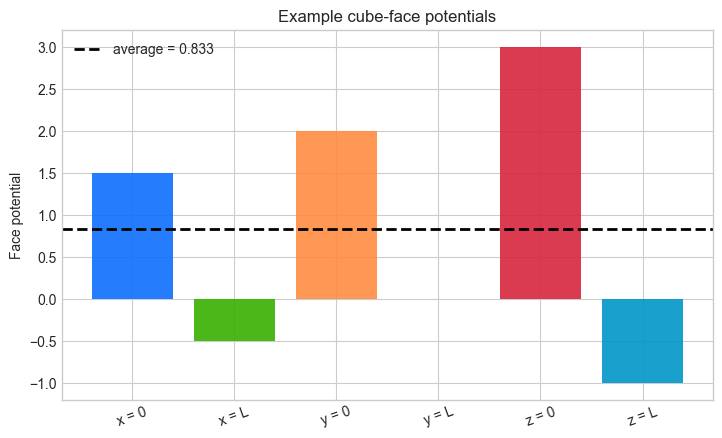

In [4]:
labels = list(face_potentials.keys())
values = np.array(list(face_potentials.values()), dtype=float)
colors = ['#0d6efd', '#38b000', '#ff8c42', '#8a5cf6', '#d7263d', '#0096c7']

fig, ax = plt.subplots(figsize=(8.4, 4.8))
bars = ax.bar(labels, values, color=colors, alpha=0.9)
ax.axhline(face_average, color='black', lw=2.0, ls='--', label=fr'average = {face_average:.3f}')
ax.set_ylabel('Face potential')
ax.set_title('Example cube-face potentials')
ax.legend()
plt.xticks(rotation=20)
plt.show()


## Numerical Illustration: The Cube as a Regular Polyhedron

The general proof above already settles the problem, but it is useful to verify the claim numerically for one of the allowed regular polyhedra. The cube corresponds to $n=6$.

We solve Laplace's equation inside a cube with constant but different face potentials using a 3D finite-difference relaxation method. The center value should converge to the average of the six face potentials.

A small technical note: when neighboring faces are held at different constant values, the edges and corners are formally discontinuous pieces of the boundary data. In the continuum problem, those measure-zero sets do not change the interior harmonic solution. In the discrete cube below, we assign edge values as averages of the adjacent faces and corner values as averages of the three touching faces.


In [5]:
def apply_cube_boundary(phi, face_values):
    fx0 = face_values['x = 0']
    fx1 = face_values['x = L']
    fy0 = face_values['y = 0']
    fy1 = face_values['y = L']
    fz0 = face_values['z = 0']
    fz1 = face_values['z = L']

    phi[0, 1:-1, 1:-1] = fx0
    phi[-1, 1:-1, 1:-1] = fx1
    phi[1:-1, 0, 1:-1] = fy0
    phi[1:-1, -1, 1:-1] = fy1
    phi[1:-1, 1:-1, 0] = fz0
    phi[1:-1, 1:-1, -1] = fz1

    phi[0, 0, 1:-1] = 0.5 * (fx0 + fy0)
    phi[0, -1, 1:-1] = 0.5 * (fx0 + fy1)
    phi[-1, 0, 1:-1] = 0.5 * (fx1 + fy0)
    phi[-1, -1, 1:-1] = 0.5 * (fx1 + fy1)

    phi[0, 1:-1, 0] = 0.5 * (fx0 + fz0)
    phi[0, 1:-1, -1] = 0.5 * (fx0 + fz1)
    phi[-1, 1:-1, 0] = 0.5 * (fx1 + fz0)
    phi[-1, 1:-1, -1] = 0.5 * (fx1 + fz1)

    phi[1:-1, 0, 0] = 0.5 * (fy0 + fz0)
    phi[1:-1, 0, -1] = 0.5 * (fy0 + fz1)
    phi[1:-1, -1, 0] = 0.5 * (fy1 + fz0)
    phi[1:-1, -1, -1] = 0.5 * (fy1 + fz1)

    phi[0, 0, 0] = (fx0 + fy0 + fz0) / 3.0
    phi[0, 0, -1] = (fx0 + fy0 + fz1) / 3.0
    phi[0, -1, 0] = (fx0 + fy1 + fz0) / 3.0
    phi[0, -1, -1] = (fx0 + fy1 + fz1) / 3.0
    phi[-1, 0, 0] = (fx1 + fy0 + fz0) / 3.0
    phi[-1, 0, -1] = (fx1 + fy0 + fz1) / 3.0
    phi[-1, -1, 0] = (fx1 + fy1 + fz0) / 3.0
    phi[-1, -1, -1] = (fx1 + fy1 + fz1) / 3.0


def solve_laplace_cube(face_values, n=25, omega=1.85, tol=1e-8, max_iter=6000):
    phi = np.empty((n, n, n), dtype=float)
    phi.fill(average_face_potential(face_values))
    apply_cube_boundary(phi, face_values)

    history = []
    for step in range(max_iter):
        max_delta = 0.0
        for i in range(1, n - 1):
            for j in range(1, n - 1):
                for k in range(1, n - 1):
                    relaxed = (
                        phi[i + 1, j, k] + phi[i - 1, j, k] +
                        phi[i, j + 1, k] + phi[i, j - 1, k] +
                        phi[i, j, k + 1] + phi[i, j, k - 1]
                    ) / 6.0
                    updated = (1.0 - omega) * phi[i, j, k] + omega * relaxed
                    delta = abs(updated - phi[i, j, k])
                    if delta > max_delta:
                        max_delta = delta
                    phi[i, j, k] = updated
        apply_cube_boundary(phi, face_values)
        history.append(max_delta)
        if max_delta < tol:
            break
    return phi, np.array(history), step + 1


In [6]:
phi_cube, history, iterations = solve_laplace_cube(face_potentials, n=25, omega=1.85, tol=1e-8, max_iter=4000)
n = phi_cube.shape[0]
center_index = n // 2
center_value = phi_cube[center_index, center_index, center_index]

print(f"Arithmetic average of the six face potentials: {face_average:.12f}")
print(f"Numerical cube-center potential:            {center_value:.12f}")
print(f"Absolute difference:                        {abs(center_value - face_average):.3e}")
print(f"Iterations used: {iterations}")


Arithmetic average of the six face potentials: 0.833333333333
Numerical cube-center potential:            0.833333333067
Absolute difference:                        2.667e-10
Iterations used: 146


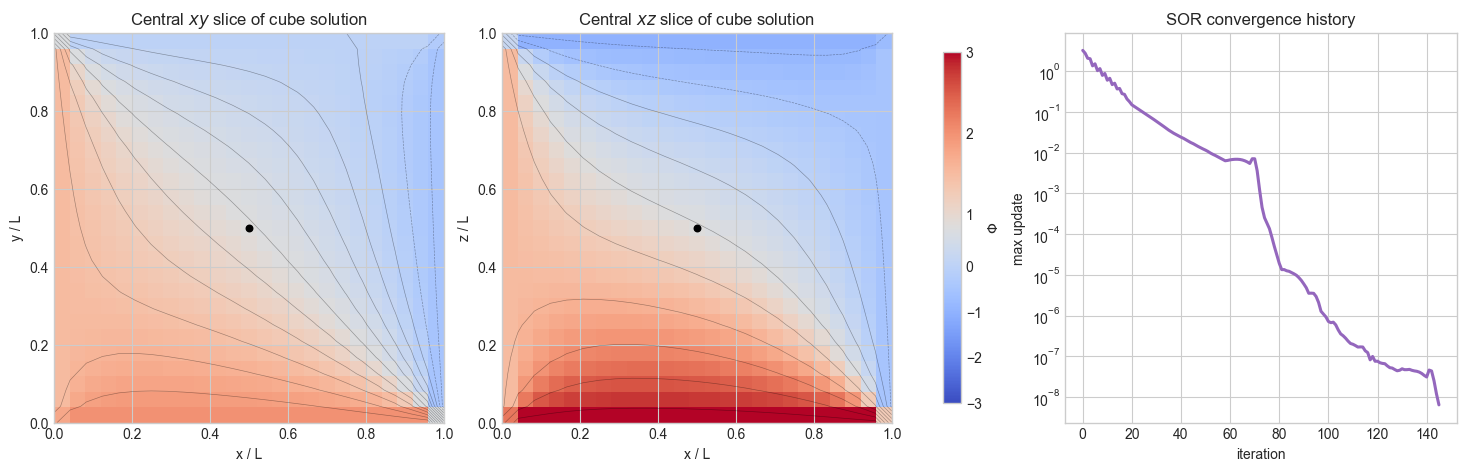

In [7]:
xy_slice = phi_cube[:, :, center_index]
xz_slice = phi_cube[:, center_index, :]
extent = (0.0, 1.0, 0.0, 1.0)
vmax = max(np.max(np.abs(xy_slice)), np.max(np.abs(xz_slice)))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=center_value, vmax=vmax)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.6), constrained_layout=True)

im0 = axes[0].imshow(xy_slice.T, origin='lower', extent=extent, cmap='coolwarm', norm=norm)
axes[0].contour(xy_slice.T, levels=12, colors='black', linewidths=0.45, alpha=0.35, extent=extent)
axes[0].scatter([0.5], [0.5], color='black', s=22)
axes[0].set_title('Central $xy$ slice of cube solution')
axes[0].set_xlabel('x / L')
axes[0].set_ylabel('y / L')

im1 = axes[1].imshow(xz_slice.T, origin='lower', extent=extent, cmap='coolwarm', norm=norm)
axes[1].contour(xz_slice.T, levels=12, colors='black', linewidths=0.45, alpha=0.35, extent=extent)
axes[1].scatter([0.5], [0.5], color='black', s=22)
axes[1].set_title('Central $xz$ slice of cube solution')
axes[1].set_xlabel('x / L')
axes[1].set_ylabel('z / L')

axes[2].semilogy(history, color='tab:purple', lw=2.2)
axes[2].set_title('SOR convergence history')
axes[2].set_xlabel('iteration')
axes[2].set_ylabel('max update')

fig.colorbar(im1, ax=axes[:2], shrink=0.9, label=r'$\Phi$')
plt.show()


## Why This Is a Mean-Value Statement

This result is the polyhedral version of a deeper mean-value principle for harmonic functions. The center does not care about the detailed route by which the field lines bend through the interior. It only cares that, by symmetry, each face gets the same weight in the harmonic average.

That is why the answer depends only on the arithmetic mean of the face potentials, not on whether the polyhedron is a tetrahedron, cube, octahedron, dodecahedron, or icosahedron. The geometry changes the field away from the center, but not the equal weighting at the center itself.


## Takeaway

Jackson 2.28 is a symmetry problem disguised as a boundary-value problem. Once linearity and equal geometric weighting are recognized, the theorem is immediate:

$$
\Phi(\text{center}) = \frac{1}{n}\sum_{i=1}^n V_i.
$$

The cube example above is only an illustration, but it shows the theorem in action: even for strongly unequal face potentials, the center value relaxes to the simple arithmetic average.
